# Massive 研究就绪检查

读取 point-in-time `MarketReplayDataset`，检查标的价格、期权报价、质量问题，并用内部定价引擎计算 IV/Greeks 与 feature。Vendor Greeks/IV 不作为事实源。对于无官方指数历史权限的 SPXW 数据，Notebook 会显式展示由同到期、同执行价 Call/Put 可见报价推导的 `synthetic_forward`，不会把它伪装成官方 SPX 点位。

In [1]:
from pathlib import Path
from decimal import Decimal
import os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / 'kairos').exists(): ROOT = ROOT.parent
DATASET_ID = os.environ.get('MASSIVE_CURATED_DATASET', 'aapl.massive.atm.20260715.https.v1')
print('dataset:', DATASET_ID)

dataset: aapl.massive.atm.20260715.https.v1


In [2]:
from kairos.data import DatasetClient
from kairos.reference import ReferenceCatalogRepository
from kairos.pricing import OptionValuationService
from kairos.study_platform.features import FeatureEngine

dataset = DatasetClient(ROOT / 'data').replay_snapshots(DATASET_ID).dataset
catalog = ReferenceCatalogRepository(ROOT / 'data/catalog/instruments.json').load()
display(pd.DataFrame({
    'source':[dataset.manifest.source], 'start':[dataset.manifest.start], 'end':[dataset.manifest.end],
    'slices':[dataset.manifest.slice_count], 'quote_coverage':[float(dataset.manifest.quote_coverage)],
    'stale_rate':[float(dataset.manifest.stale_rate)], 'content_hash':[dataset.manifest.content_hash],
}))

,source,start,end,slices,quote_coverage,stale_rate,content_hash
0,massive.canonical:options.us.massive.aapl.atm....,2026-07-15 13:30:00+00:00,2026-07-15 13:35:00+00:00,5,0.8,0.0,7c141cad0304d78e693a1ee8ea2d983e73ee5c31ace835...


,timestamp,instruments,quoted,reference_prices,errors,warnings
0,2026-07-15 13:30:00+00:00,6,0,1,6,0
1,2026-07-15 13:31:00+00:00,6,6,1,0,0
2,2026-07-15 13:32:00+00:00,6,6,1,0,0
3,2026-07-15 13:33:00+00:00,6,6,1,0,0
4,2026-07-15 13:34:00+00:00,6,6,1,0,0


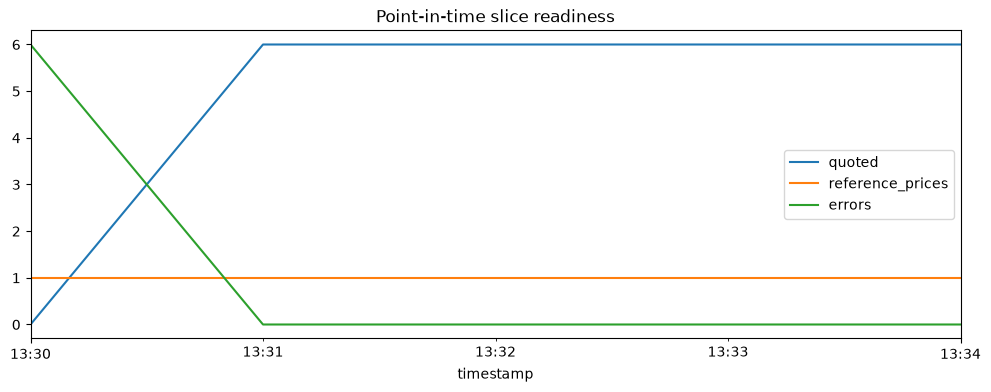

In [3]:
slice_rows = []
for market in dataset.slices:
    slice_rows.append({
        'timestamp': market.timestamp, 'instruments': len(market.instruments),
        'quoted': sum(item.quote is not None for item in market.instruments),
        'reference_prices': len(market.reference_prices),
        'reference_mode': ('synthetic_forward' if any(issue.code == 'synthetic_forward' for issue in market.quality_issues) else ('official' if market.reference_prices else 'missing')),
        'errors': sum(issue.severity == 'error' for issue in market.quality_issues),
        'warnings': sum(issue.severity == 'warning' for issue in market.quality_issues),
    })
slices = pd.DataFrame(slice_rows)
display(slices)
slices.set_index('timestamp')[['quoted','reference_prices','errors']].plot(figsize=(12,4), title='Point-in-time slice readiness')
plt.show()

In [4]:
valuation_service = OptionValuationService(catalog, max_quote_age_seconds=Decimal(str(max(5, dataset.manifest.sampling_seconds))))
feature_engine = FeatureEngine()
valuation_rows = []
for market in dataset.slices:
    valued, valuation = valuation_service.value(market)
    feature = feature_engine.update(valuation)
    for item in valuation.instruments:
        valuation_rows.append({
            'timestamp': market.timestamp, 'instrument_id': item.instrument_id.value,
            'market_price': float(item.market_price),
            'internal_iv': float(item.implied_vol.volatility) if item.implied_vol.volatility is not None else None,
            'delta': float(item.pricing.delta) if item.pricing is not None else None,
            'gamma': float(item.pricing.gamma) if item.pricing is not None else None,
            'average_iv_feature': float(feature.average_implied_vol) if feature.average_implied_vol is not None else None,
            'failure_count': len(valuation.failures),
        })
valuations = pd.DataFrame(valuation_rows)
display(valuations)
assert not valuations.empty, 'No internally priceable quote was produced'

,timestamp,instrument_id,market_price,internal_iv,delta,gamma,average_iv_feature,failure_count
0,2026-07-15 13:31:00+00:00,option:us:AAPL260717C00315000,5.250,0.302897,0.692372,0.045847,0.304459,0
1,2026-07-15 13:31:00+00:00,option:us:AAPL260717C00317500,3.775,0.311423,0.569220,0.051356,0.304459,0
2,2026-07-15 13:31:00+00:00,option:us:AAPL260717C00320000,2.430,0.300489,0.439291,0.051657,0.304459,0
3,2026-07-15 13:31:00+00:00,option:us:AAPL260717P00315000,1.525,0.304597,-0.307628,0.045847,0.304459,0
4,2026-07-15 13:31:00+00:00,option:us:AAPL260717P00317500,2.455,0.303322,-0.430780,0.051356,0.304459,0
5,2026-07-15 13:31:00+00:00,option:us:AAPL260717P00320000,3.725,0.304022,-0.560709,0.051657,0.304459,0
6,2026-07-15 13:32:00+00:00,option:us:AAPL260717C00315000,5.300,0.302301,0.698669,0.046118,0.298662,0
7,2026-07-15 13:32:00+00:00,option:us:AAPL260717C00317500,3.725,0.301774,0.574149,0.051896,0.298662,0
8,2026-07-15 13:32:00+00:00,option:us:AAPL260717C00320000,2.480,0.302022,0.442723,0.052265,0.298662,0
9,2026-07-15 13:32:00+00:00,option:us:AAPL260717P00315000,1.445,0.298302,-0.301331,0.046118,0.298662,0


,status,observations,priceable
0,READY_FOR_INTERNAL_IV,24,24


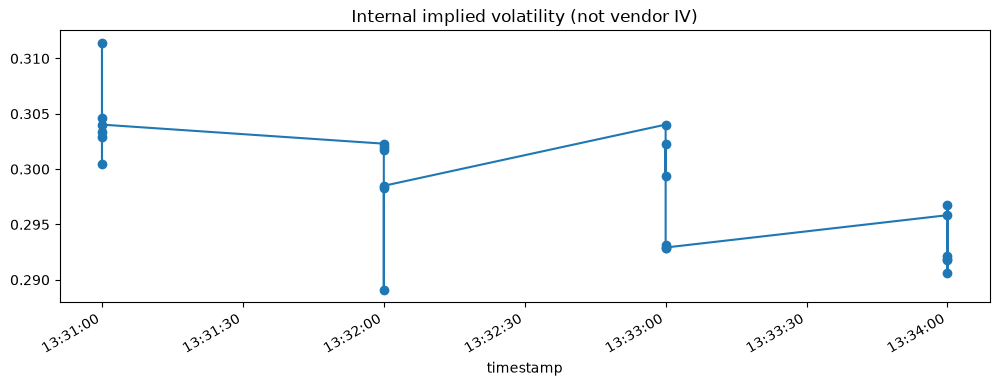

,internal_iv,delta,gamma,failure_count
count,24.000000,24.000000,24.000000,24.0
mean,0.298432,0.054077,0.050732,0.0
std,0.005696,0.522367,0.002644,0.0
min,0.289079,-0.605700,0.045847,0.0
25%,0.292904,-0.434770,0.049062,0.0
50%,0.298938,0.046485,0.051678,0.0
75%,0.302450,0.557250,0.052434,0.0
max,0.311423,0.698669,0.053884,0.0


In [5]:
priceable = valuations.dropna(subset=['internal_iv'])
status = 'READY_FOR_INTERNAL_IV' if len(priceable) else 'DATA_VISIBLE_BUT_NOT_PRICEABLE'
display(pd.DataFrame({'status':[status], 'observations':[len(valuations)], 'priceable':[len(priceable)]}))
if not priceable.empty:
    priceable.set_index('timestamp')['internal_iv'].plot(figsize=(12,4), marker='o', title='Internal implied volatility (not vendor IV)')
    plt.show()
else:
    print('Quotes are readable, but this smoke contract fails internal IV bounds. Select liquid near-ATM contracts before study.')
display(valuations[['internal_iv','delta','gamma','failure_count']].describe())